# Project 4 - Risk Averse, LLC: Iowa & Wisconsin Natural Hazard Risk Analysis
**Hazards:** Drought | Lightning  
**States:** Iowa | Wisconsin  
**Client:** Risk Averse, LLC  

---

## Task 1 – Import Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

from PIL import Image
from IPython.display import display

## Task 2 - Load NRI Census Tract Data (Iowa & Wisconsin)
Data downloaded from: https://hazards.fema.gov/nri/data-resources

In [2]:
ia_nri = pd.read_csv("NRI_Table_CensusTracts_Iowa.csv")
wi_nri = pd.read_csv("NRI_Table_CensusTracts_Wisconsin.csv")

print("Iowa NRI shape:", ia_nri.shape)
print("Wisconsin NRI shape:", wi_nri.shape)
ia_nri.head(3)

Iowa NRI shape: (896, 467)
Wisconsin NRI shape: (1526, 467)


,OID_,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,...,WNTW_EALS,WNTW_EALR,WNTW_ALRB,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_NPCTL,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER
0,29850,T19001960100,Iowa,IA,19,Adair,County,1,19001,960100,...,97.253212,Relatively High,0.000025,2.721530e-07,0.000002,95.475257,38400.296430,96.903392,Relatively High,March 2023
1,29851,T19001960200,Iowa,IA,19,Adair,County,1,19001,960200,...,95.896846,Relatively High,0.000025,2.721530e-07,0.000002,95.518707,22311.637748,93.925700,Relatively High,March 2023
2,29852,T19001960300,Iowa,IA,19,Adair,County,1,19001,960300,...,96.492238,Relatively High,0.000025,2.721530e-07,0.000002,95.394227,31483.696562,95.974647,Relatively High,March 2023


## Task 3 - Load NRI Metadata File
Using the NRI Data Dictionary to clarify variable definitions in the dataset.

In [3]:
nri_dictionary = pd.read_csv("NRIDataDictionary.csv")
print(nri_dictionary.shape)
nri_dictionary.head(10)

(479, 9)


,Sort,Field Name,Field Alias,Type,Length,Relevant Layer,Metric Type,Version,Version Date
0,1,OBJECTID,OBJECTID,Integer,4.0,NaN,NaN,1.19.0,March 2023
1,2,Shape,Shape,Geometry,NaN,NaN,NaN,1.19.0,March 2023
2,3,Shape_Length,Shape_Length,Double,8.0,NaN,NaN,1.19.0,March 2023
3,4,Shape_Area,Shape_Area,Double,8.0,NaN,NaN,1.19.0,March 2023
4,5,STATE,State Name,String,250.0,All,NaN,1.19.0,March 2023
5,6,STATEABBRV,State Name Abbreviation,String,20.0,All,NaN,1.19.0,March 2023
6,7,STATEFIPS,State FIPS Code,String,20.0,All,NaN,1.19.0,March 2023
7,8,COUNTY,County Name,String,250.0,All,NaN,1.19.0,March 2023
8,9,COUNTYTYPE,County Type,String,250.0,All,NaN,1.19.0,March 2023
9,10,COUNTYFIPS,County FIPS Code,String,20.0,All,NaN,1.19.0,March 2023


## Task 4 - Load SVI Data (Iowa & Wisconsin)
Data downloaded from: https://www.atsdr.cdc.gov/place-health/php/svi/svi-data-documentation-download.html

In [4]:
ia_svi = pd.read_csv("Iowa.csv")
wi_svi = pd.read_csv("Wisconsin.csv")

print("Iowa SVI shape:", ia_svi.shape)
print("Wisconsin SVI shape:", wi_svi.shape)
ia_svi.head(3)

Iowa SVI shape: (896, 158)
Wisconsin SVI shape: (1528, 158)


,ST,STATE,ST_ABBR,STCNTY,COUNTY,FIPS,LOCATION,AREA_SQMI,E_TOTPOP,M_TOTPOP,...,EP_ASIAN,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE
0,19,Iowa,IA,19001,Adair County,19001960100,Census Tract 9601; Adair County; Iowa,273.329109,2813,185,...,0.0,0.9,0.0,0.9,0.0,0.9,1.1,0.8,0.0,0.9
1,19,Iowa,IA,19001,Adair County,19001960200,Census Tract 9602; Adair County; Iowa,257.170375,1737,142,...,0.0,1.4,0.0,1.4,0.7,1.0,0.7,0.8,1.5,1.9
2,19,Iowa,IA,19001,Adair County,19001960300,Census Tract 9603; Adair County; Iowa,38.770927,2929,203,...,0.3,0.4,0.0,0.8,0.0,0.8,2.6,1.2,0.8,1.1


## Task 5 - Join NRI and SVI Datasets
Both datasets share a FIPS code used as the merge key.

In [5]:
# Iowa – create FIPS key and merge
ia_nri["FIPS"] = ia_nri["STCOFIPS"].astype(str) + ia_nri["TRACT"].astype(str)
ia_svi["FIPS"] = ia_svi["FIPS"].astype(str)
ia_nri["FIPS"] = ia_nri["FIPS"].astype(str)

ia_complete = pd.merge(ia_nri, ia_svi, on="FIPS", suffixes=("", "_right"))
print("Iowa merged shape:", ia_complete.shape)

Iowa merged shape: (284, 625)


In [6]:
# Wisconsin – create FIPS key and merge
wi_nri["FIPS"] = wi_nri["STCOFIPS"].astype(str) + wi_nri["TRACT"].astype(str)
wi_svi["FIPS"] = wi_svi["FIPS"].astype(str)
wi_nri["FIPS"] = wi_nri["FIPS"].astype(str)

wi_complete = pd.merge(wi_nri, wi_svi, on="FIPS", suffixes=("", "_right"))
print("Wisconsin merged shape:", wi_complete.shape)

Wisconsin merged shape: (642, 625)


## Task 6 - Handle Missing Values
Check for NAs, drop all-NA columns, and impute remaining NAs with 0.

In [8]:
# Check for missing values
print("Iowa NRI – columns with missing values:")
print(ia_nri.isna().sum()[ia_nri.isna().sum() > 0])

print("Wisconsin NRI – columns with missing values:")
print(wi_nri.isna().sum()[wi_nri.isna().sum() > 0])

Iowa NRI – columns with missing values:
AVLN_EVNTS        896
AVLN_AFREQ        896
AVLN_EXP_AREA     896
AVLN_EXPB         896
AVLN_EXPP         896
                 ... 
VLCN_ALRP         896
VLCN_ALR_NPCTL    896
VLCN_RISKV        896
VLCN_RISKS        896
WFIR_EVNTS        896
Length: 101, dtype: int64
Wisconsin NRI – columns with missing values:
AVLN_EVNTS        1526
AVLN_AFREQ        1526
AVLN_EXP_AREA     1526
AVLN_EXPB         1526
AVLN_EXPP         1526
                  ... 
VLCN_ALRP         1526
VLCN_ALR_NPCTL    1526
VLCN_RISKV        1526
VLCN_RISKS        1526
WFIR_EVNTS        1526
Length: 101, dtype: int64


In [9]:
# Drop columns where ALL values are NA
ia_complete = ia_complete.dropna(axis=1, how="all")
wi_complete = wi_complete.dropna(axis=1, how="all")

# Fill remaining NAs with 0 (imputation choice: avoids data loss)
ia_complete = ia_complete.fillna(0)
wi_complete = wi_complete.fillna(0)

print("Iowa NAs remaining:", ia_complete.isna().sum().sum())
print("Wisconsin NAs remaining:", wi_complete.isna().sum().sum())

Iowa NAs remaining: 0
Wisconsin NAs remaining: 0


## Task 7 - NRI Risk Definitions
The NRI defines risk as Expected Annual Loss × Social Vulnerability × Community Resilience.  
The  column captures the composite NRI risk score for each Census tract.  
Hazard-specific scores (e.g., , ) capture individual hazard risk percentiles.

In [10]:
# Inspect existing NRI risk columns for drought and lightning
nri_cols = ["TRACTFIPS", "COUNTY", "RISK_SCORE", "RISK_RATNG",
            "DRGT_RISKS", "DRGT_RISKR",
            "LTNG_RISKS", "LTNG_RISKR"]

print("Iowa – NRI risk columns:")
print(ia_complete[nri_cols].head(5))

print("Wisconsin – NRI risk columns:")
print(wi_complete[nri_cols].head(5))

Iowa – NRI risk columns:
     TRACTFIPS COUNTY  RISK_SCORE           RISK_RATNG  DRGT_RISKS  \
0  19001960100  Adair   86.691956      Relatively High   99.037958   
1  19001960200  Adair   75.526804  Relatively Moderate   98.168672   
2  19001960300  Adair   76.013176  Relatively Moderate   94.961471   
3  19003950100  Adams   76.436522  Relatively Moderate   98.724017   
4  19003950200  Adams   75.934691  Relatively Moderate   96.315940   

            DRGT_RISKR  LTNG_RISKS           LTNG_RISKR  
0      Relatively High   54.526833  Relatively Moderate  
1  Relatively Moderate   35.676809       Relatively Low  
2  Relatively Moderate   50.402492  Relatively Moderate  
3      Relatively High   42.034020       Relatively Low  
4  Relatively Moderate   52.383805  Relatively Moderate  
Wisconsin – NRI risk columns:
     TRACTFIPS COUNTY  RISK_SCORE           RISK_RATNG  DRGT_RISKS DRGT_RISKR  \
0  55001950100  Adams   51.186795       Relatively Low   71.526423   Very Low   
1  55001950201

## Task 8 - Proposed (Alternative) Risk Definition
**Classic risk definition:** Risk = Probability of Event × Impact of Event  
Our proposed definition multiplies hazard **annual frequency** (probability proxy) by **exposure** (impact proxy):

-  (frequency × agricultural exposure)
-  (frequency × population exposure)
-  (frequency × agricultural loss rate – third column)

In [11]:
# Iowa – create proposed risk columns
ia_complete["drought_risk"] = ia_complete["DRGT_AFREQ"] * ia_complete["DRGT_EXPA"]
ia_complete["lightning_risk"] = ia_complete["LTNG_AFREQ"] * ia_complete["LTNG_EXPP"]
ia_complete["ag_loss_risk"] = ia_complete["DRGT_AFREQ"] * ia_complete["DRGT_ALRA"]

print(ia_complete[["drought_risk", "lightning_risk", "ag_loss_risk"]].describe())

       drought_risk  lightning_risk  ag_loss_risk
count  2.840000e+02      284.000000    284.000000
mean   2.913940e+08   201711.377458      0.022645
std    3.536253e+08    73540.929725      0.022061
min    0.000000e+00        0.000000      0.000000
25%    1.521789e+07   148993.236694      0.006323
50%    1.365107e+08   192597.026699      0.016361
75%    4.558555e+08   247483.569622      0.030682
max    1.693535e+09   430724.433247      0.098252


In [12]:
# Wisconsin – create proposed risk columns
wi_complete["drought_risk"] = wi_complete["DRGT_AFREQ"] * wi_complete["DRGT_EXPA"]
wi_complete["lightning_risk"] = wi_complete["LTNG_AFREQ"] * wi_complete["LTNG_EXPP"]
wi_complete["ag_loss_risk"] = wi_complete["DRGT_AFREQ"] * wi_complete["DRGT_ALRA"]

print(wi_complete[["drought_risk", "lightning_risk", "ag_loss_risk"]].describe())

       drought_risk  lightning_risk  ag_loss_risk
count  6.420000e+02      642.000000    642.000000
mean   6.847993e+06   152786.388263      0.000132
std    2.209594e+07    77948.982952      0.000475
min    0.000000e+00      384.404589      0.000000
25%    0.000000e+00    94763.216033      0.000000
50%    1.405762e+05   146619.888935      0.000003
75%    2.634054e+06   200321.105907      0.000018
max    2.164042e+08   479231.800120      0.004921


## Task 9 - Summary Tables and Figures
At least two summary tables or figures comparing NRI risk scores to our proposed risk definition.

### Figure 1 - 0 Iowa: NRI Risk Score vs. Proposed Drought Risk by County

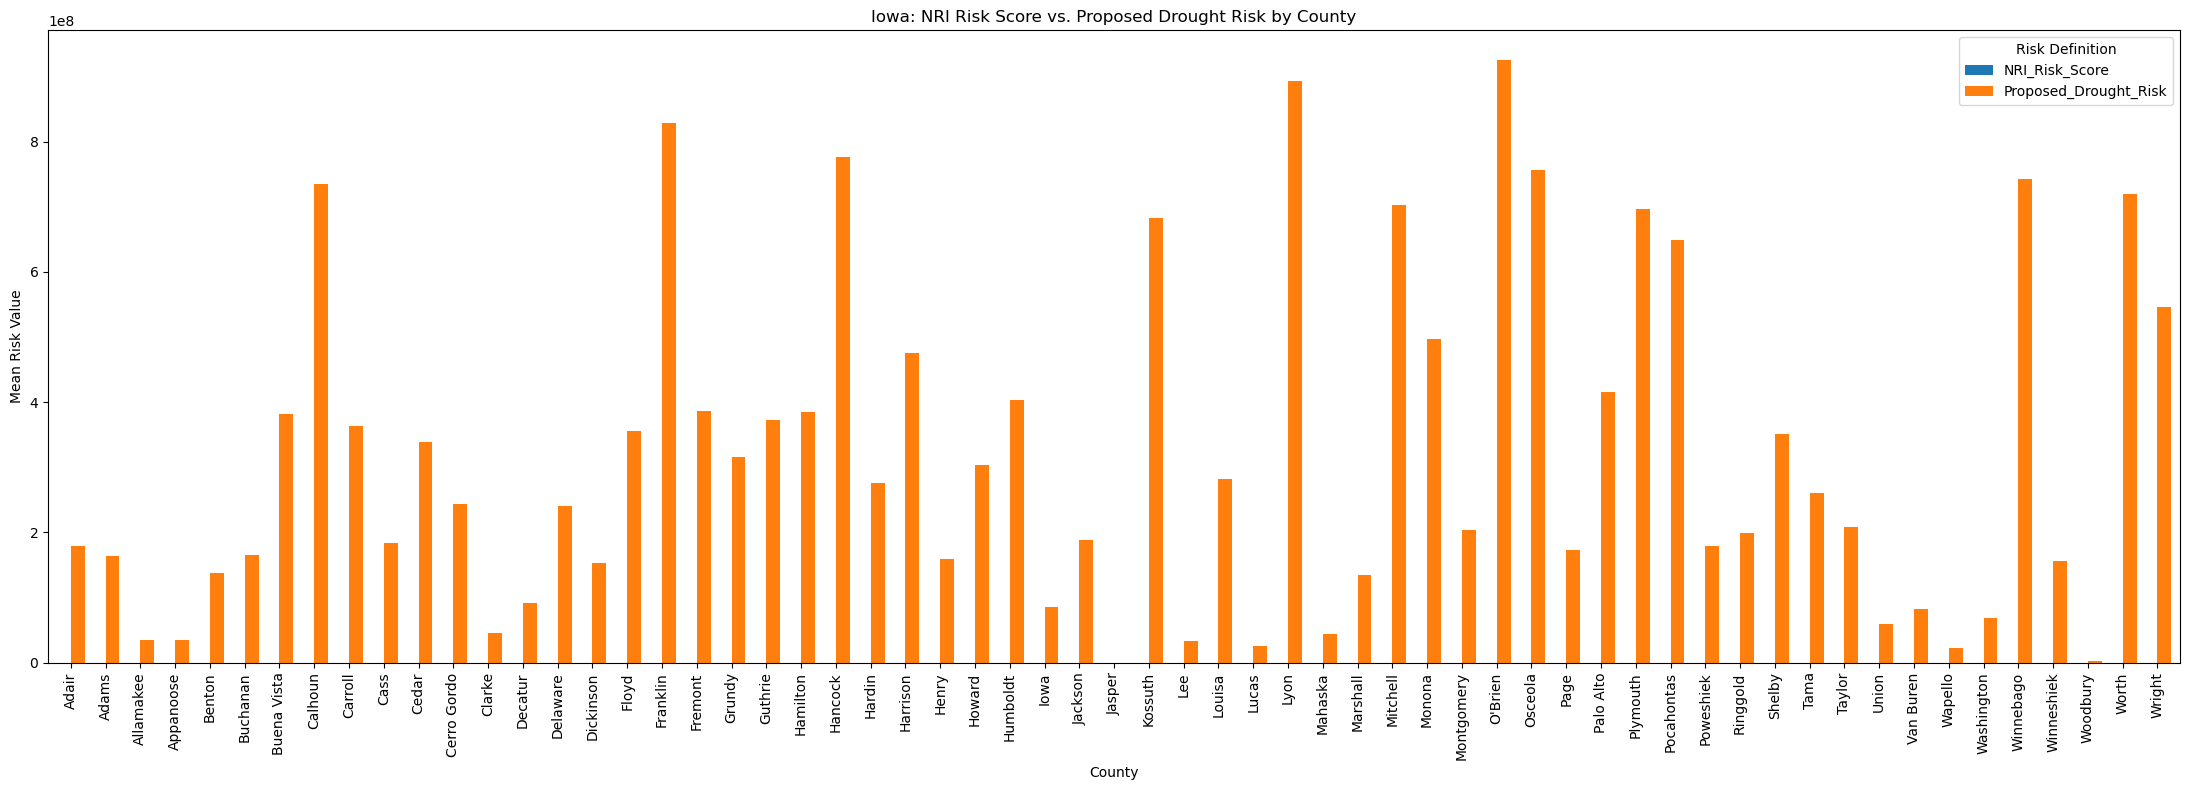

In [13]:
ia_grouped = ia_complete.groupby("COUNTY").agg(
    NRI_Risk_Score=("RISK_SCORE", "mean"),
    Proposed_Drought_Risk=("drought_risk", "mean"),
    Proposed_Lightning_Risk=("lightning_risk", "mean")
).reset_index()

ia_grouped.set_index("COUNTY")[["NRI_Risk_Score", "Proposed_Drought_Risk"]].plot(
    kind="bar", figsize=(22, 8), width=0.8
)
plt.xlabel("County")
plt.ylabel("Mean Risk Value")
plt.title("Iowa: NRI Risk Score vs. Proposed Drought Risk by County")
plt.xticks(rotation=90)
plt.legend(title="Risk Definition")
plt.tight_layout()
plt.show()

### Figure 2 - Wisconsin: NRI Risk Score vs. Proposed Lightning Risk by County

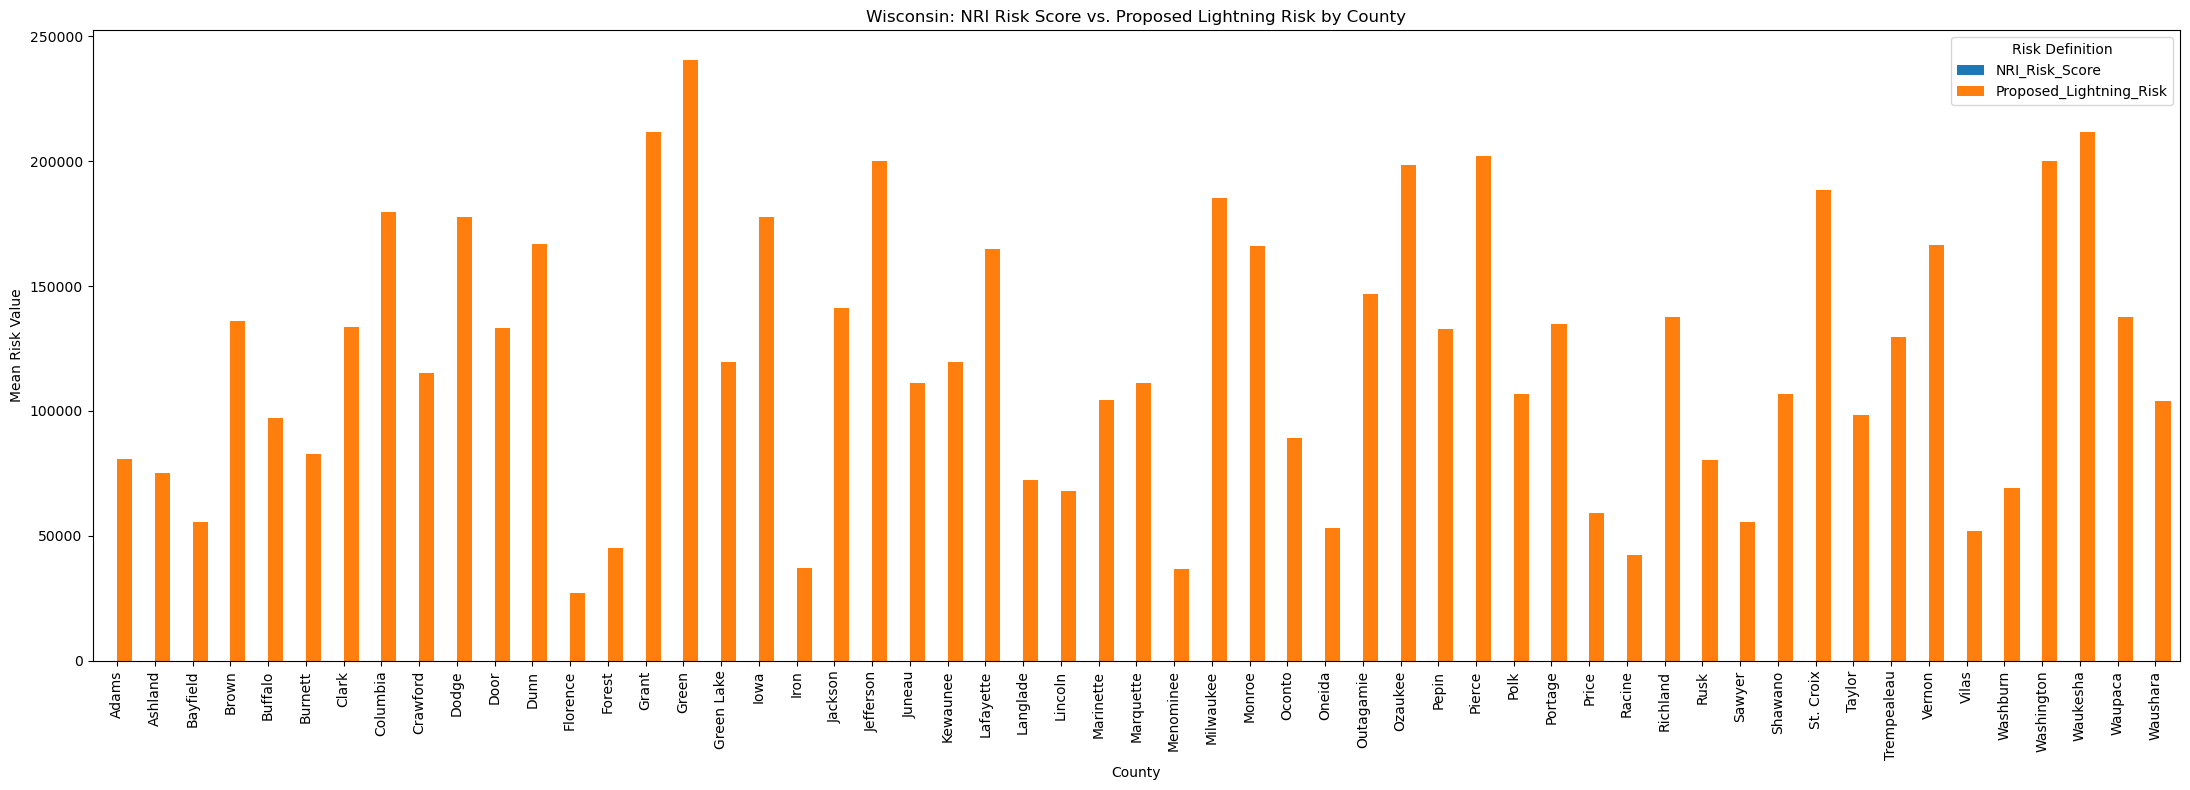

In [14]:
wi_grouped = wi_complete.groupby("COUNTY").agg(
    NRI_Risk_Score=("RISK_SCORE", "mean"),
    Proposed_Drought_Risk=("drought_risk", "mean"),
    Proposed_Lightning_Risk=("lightning_risk", "mean")
).reset_index()

wi_grouped.set_index("COUNTY")[["NRI_Risk_Score", "Proposed_Lightning_Risk"]].plot(
    kind="bar", figsize=(22, 8), width=0.8
)
plt.xlabel("County")
plt.ylabel("Mean Risk Value")
plt.title("Wisconsin: NRI Risk Score vs. Proposed Lightning Risk by County")
plt.xticks(rotation=90)
plt.legend(title="Risk Definition")
plt.tight_layout()
plt.show()

### Table 1 - Iowa: Top 10 Counties by Proposed Drought Risk

In [15]:
ia_top10_drought = ia_grouped.nlargest(10, "Proposed_Drought_Risk")[
    ["COUNTY", "NRI_Risk_Score", "Proposed_Drought_Risk"]
]
print(ia_top10_drought.to_string(index=False))

   COUNTY  NRI_Risk_Score  Proposed_Drought_Risk
  O'Brien       90.121236           9.248229e+08
     Lyon       77.256655           8.931458e+08
 Franklin       83.708716           8.294691e+08
  Hancock       73.944311           7.760583e+08
  Osceola       94.420397           7.570763e+08
Winnebago       75.232285           7.432075e+08
  Calhoun       87.534189           7.355969e+08
    Worth       71.778925           7.193069e+08
 Mitchell       77.340294           7.027987e+08
 Plymouth       63.043254           6.967920e+08


### Table 2 - Wisconsin: Top 10 Counties by Proposed Lightning Risk

In [16]:
wi_top10_lightning = wi_grouped.nlargest(10, "Proposed_Lightning_Risk")[
    ["COUNTY", "NRI_Risk_Score", "Proposed_Lightning_Risk"]
]
print(wi_top10_lightning.to_string(index=False))

    COUNTY  NRI_Risk_Score  Proposed_Lightning_Risk
     Green       57.925546            240331.455978
     Grant       60.894615            211753.986732
  Waukesha       26.722858            211546.636205
    Pierce       78.774140            202013.920834
Washington       39.385673            200214.526968
 Jefferson       57.550177            200019.862486
   Ozaukee       27.431917            198587.505046
 St. Croix       64.127450            188585.721965
 Milwaukee       26.979201            185410.540863
  Columbia       64.873820            179490.069236


## Task 10 - GeoPandas Maps
At least one map communicating risk information to the client.  
We produce four maps: NRI Risk Score and Proposed Risk for each state.

In [17]:
# Load and reproject shapefile
tracts = gpd.read_file("NRI_Shapefile_CensusTracts.shp")

tracts_clean = tracts.set_crs(epsg=4326, inplace=True, allow_override=True)
tracts_clean = tracts_clean.to_crs(epsg=4326)
tracts_clean = tracts_clean.replace(-9999, np.nan)

tracts_clean.crs = "EPSG:3857"
tracts_clean = tracts_clean.to_crs(epsg=4326)
tracts_clean = tracts_clean.to_crs("ESRI:102003")

# Add proposed risk columns to shapefile data
tracts_clean["drought_risk"] = tracts_clean["DRGT_AFREQ"] * tracts_clean["DRGT_EXPA"]
tracts_clean["lightning_risk"] = tracts_clean["LTNG_AFREQ"] * tracts_clean["LTNG_EXPP"]

print(tracts_clean.crs)
print(tracts_clean.shape)

ESRI:102003
(85154, 471)


### Map Helper Function

In [18]:
def plot_state_map(gdf, state_name, column, title, label):
    state_map = gdf[gdf["STATE"].str.lower() == state_name.lower()]
    fig, ax = plt.subplots(1, 1, figsize=(18, 10))
    state_map.plot(
        column=column, ax=ax, legend=True, linewidth=0.0,
        cmap="RdYlBu_r",
        legend_kwds={"label": label, "orientation": "horizontal", "shrink": 0.6, "pad": 0.05},
        missing_kwds={"color": "lightgray", "label": "No Data"}
    )
    minx, miny, maxx, maxy = state_map.total_bounds
    padding = 0.5
    ax.set_xlim(minx - padding, maxx + padding)
    ax.set_ylim(miny - padding, maxy + padding)
    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

### Map 1 - Iowa: NRI Risk Score (existing definition)

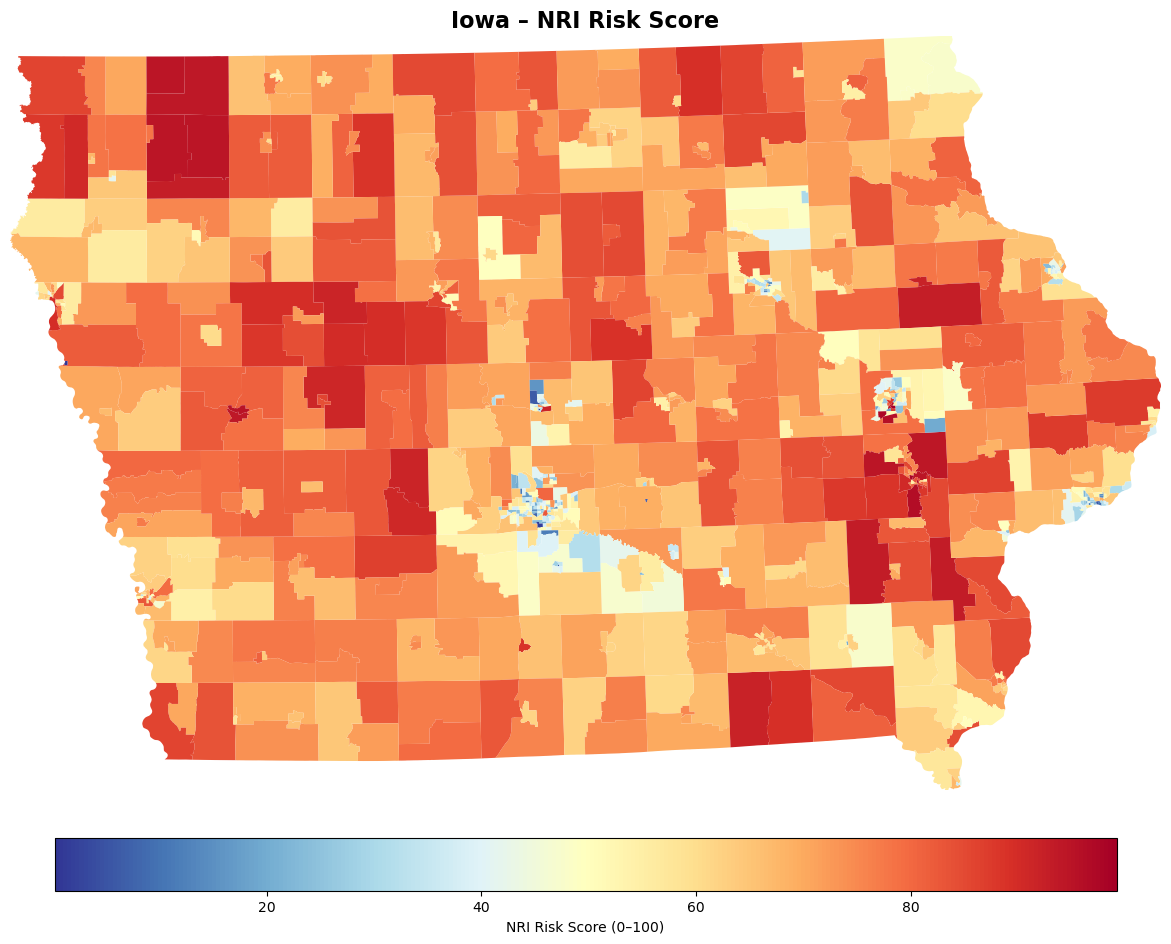

In [19]:
plot_state_map(tracts_clean, "Iowa", "RISK_SCORE", "Iowa – NRI Risk Score", "NRI Risk Score (0–100)")

### Map 2 - Iowa: Proposed Drought Risk

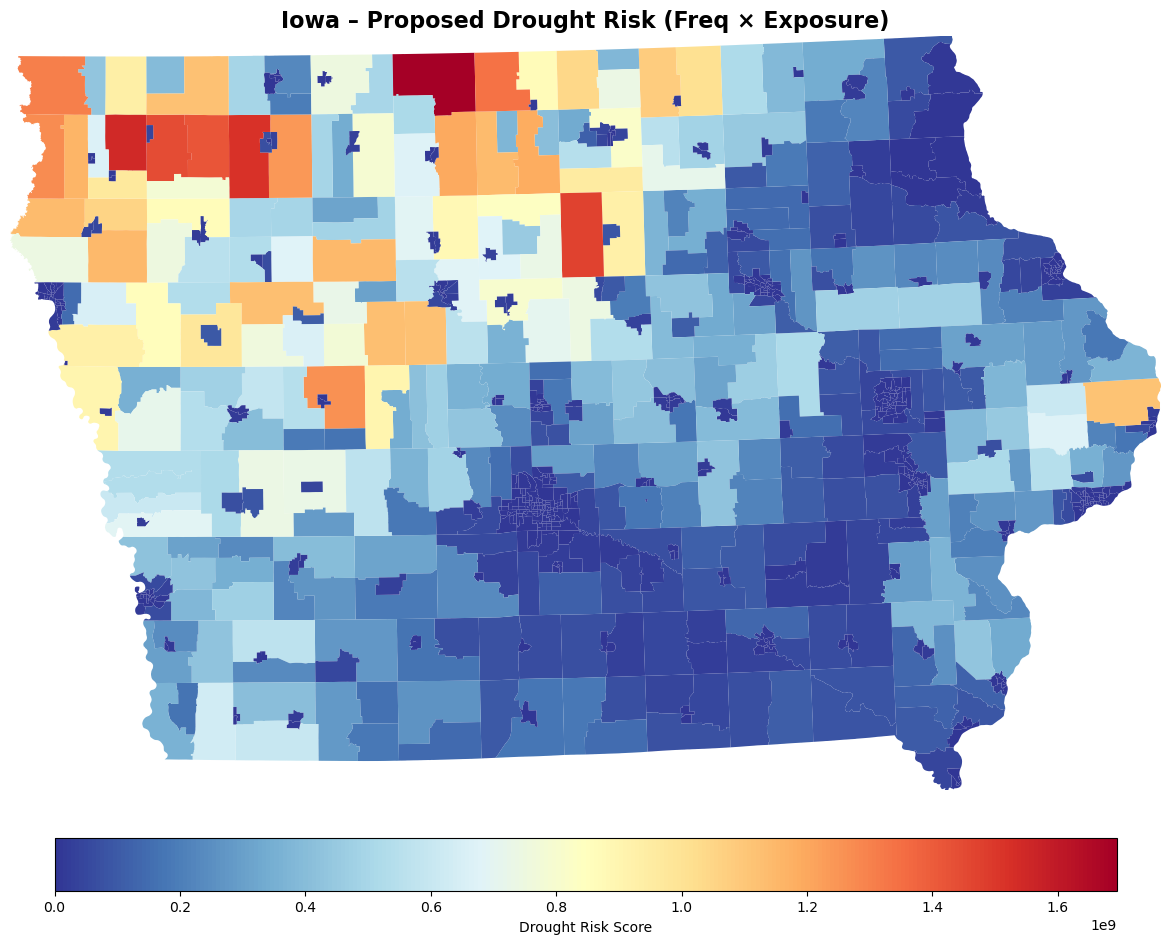

In [20]:
plot_state_map(tracts_clean, "Iowa", "drought_risk", "Iowa – Proposed Drought Risk (Freq × Exposure)", "Drought Risk Score")

### Map 3 - Wisconsin: NRI Risk Score (existing definition)

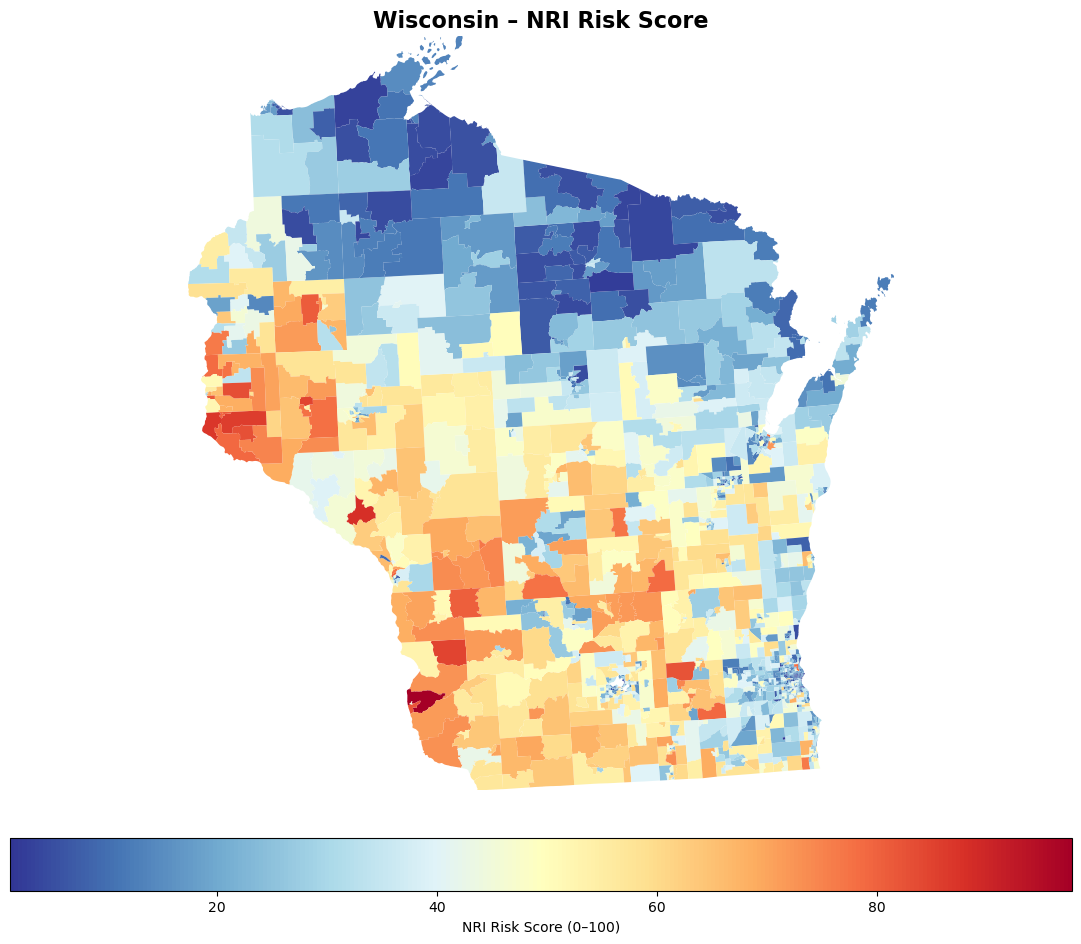

In [21]:
plot_state_map(tracts_clean, "Wisconsin", "RISK_SCORE", "Wisconsin – NRI Risk Score", "NRI Risk Score (0–100)")

### Map 4 - Wisconsin: Proposed Lightning Risk

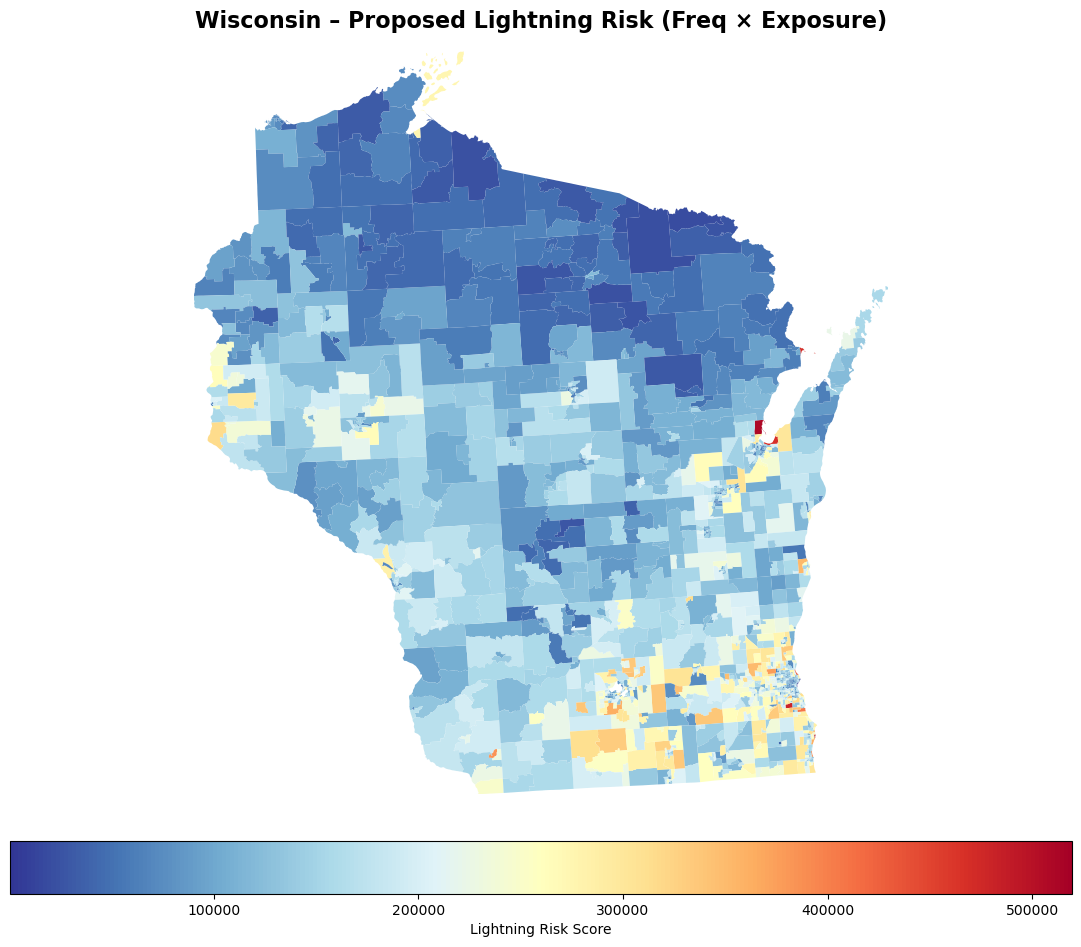

In [22]:
plot_state_map(tracts_clean, "Wisconsin", "lightning_risk", "Wisconsin – Proposed Lightning Risk (Freq × Exposure)", "Lightning Risk Score")

### Map 5 - Iowa: NRI Risk Rating Choropleth (categorical bias comparison)

C:\Users\levid\AppData\Local\Temp\ipykernel_40748\2154692940.py:19: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(title="Risk Rating", loc="lower left", fontsize=9)
C:\Users\levid\AppData\Local\Temp\ipykernel_40748\2154692940.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Risk Rating", loc="lower left", fontsize=9)


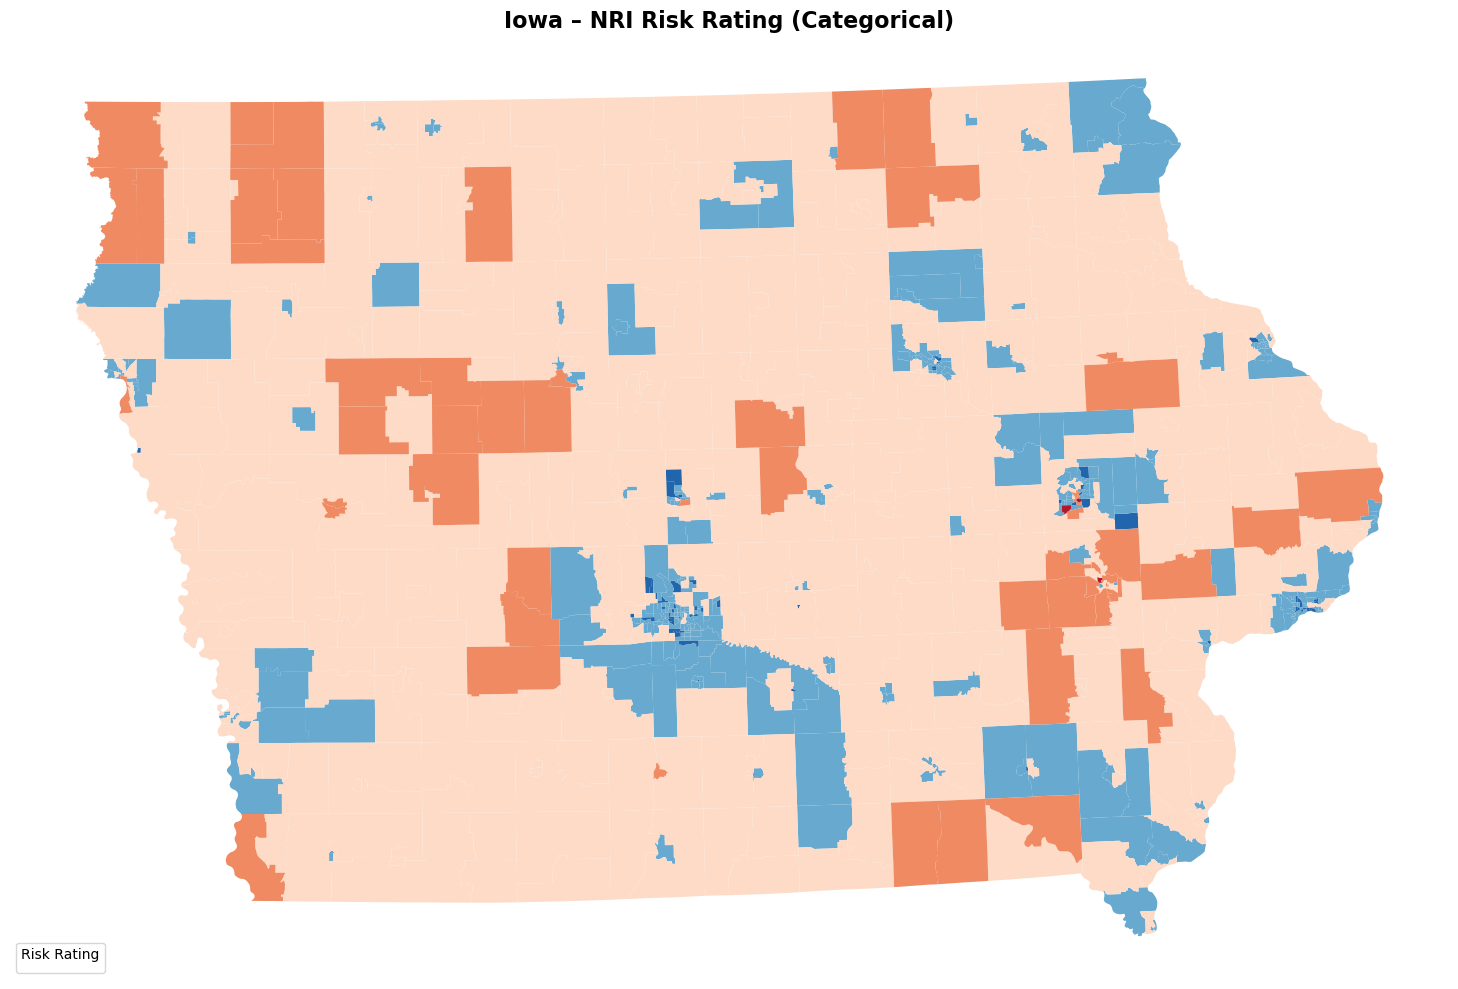

In [23]:
rating_order = ["Very Low", "Relatively Low", "Relatively Moderate", "Relatively High", "Very High"]
rating_colors = {
    "Very Low": "#2166ac",
    "Relatively Low": "#67a9cf",
    "Relatively Moderate": "#fddbc7",
    "Relatively High": "#ef8a62",
    "Very High": "#b2182b",
}

ia_map = tracts_clean[tracts_clean["STATE"].str.lower() == "iowa"]
rated = ia_map[ia_map["RISK_RATNG"].isin(rating_order)]

fig, ax = plt.subplots(1, 1, figsize=(18, 10))
for rating in rating_order:
    subset = rated[rated["RISK_RATNG"] == rating]
    if not subset.empty:
        subset.plot(ax=ax, color=rating_colors[rating], linewidth=0.0, label=rating)

ax.legend(title="Risk Rating", loc="lower left", fontsize=9)
ax.set_title("Iowa – NRI Risk Rating (Categorical)", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

### Map 6 - Wisconsin: NRI Risk Rating Choropleth (categorical bias comparison)

C:\Users\levid\AppData\Local\Temp\ipykernel_40748\2287758576.py:10: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(title="Risk Rating", loc="lower left", fontsize=9)
C:\Users\levid\AppData\Local\Temp\ipykernel_40748\2287758576.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Risk Rating", loc="lower left", fontsize=9)


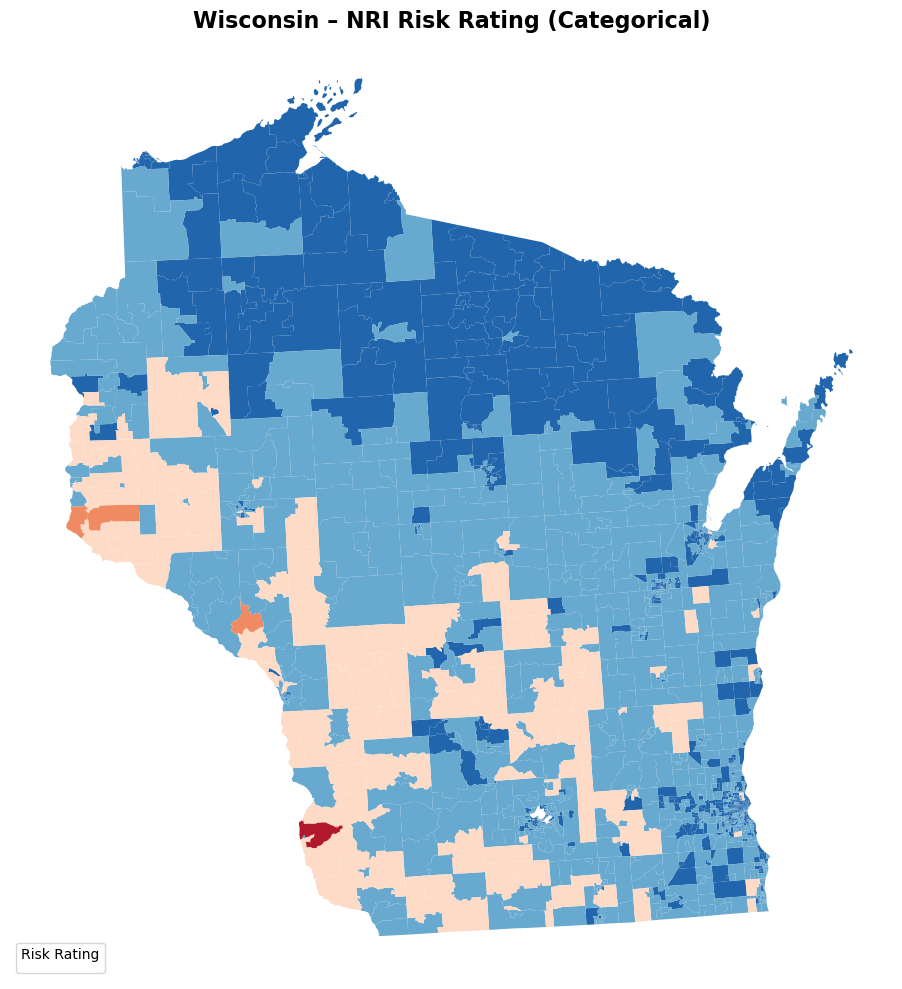

In [24]:
wi_map = tracts_clean[tracts_clean["STATE"].str.lower() == "wisconsin"]
rated_wi = wi_map[wi_map["RISK_RATNG"].isin(rating_order)]

fig, ax = plt.subplots(1, 1, figsize=(18, 10))
for rating in rating_order:
    subset = rated_wi[rated_wi["RISK_RATNG"] == rating]
    if not subset.empty:
        subset.plot(ax=ax, color=rating_colors[rating], linewidth=0.0, label=rating)

ax.legend(title="Risk Rating", loc="lower left", fontsize=9)
ax.set_title("Wisconsin – NRI Risk Rating (Categorical)", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()